In [1]:
import numpy as np
import pandas as pd

# Checking pollution data_set

In [2]:
pollution= pd.read_csv(r"C:\Users\mugil\Desktop\Pollution_Forecast_Dublin\data\extracted\airview\AirView_DublinCity_Measurements_ugm3.csv")

In [3]:
print(pollution.columns.tolist())

['gps_timestamp', 'latitude', 'longitude', 'NO_ugm3', 'NO2_ugm3', 'O3_ugm3', 'CO_mgm3', 'CO2_mgm3', 'PMch1_perL', 'PMch2_perL', 'PMch3_perL', 'PMch4_perL', 'PMch5_perL', 'PMch6_perL', 'PM25_ugm3']


# Removing unwanted column
### Multiple properties of pollution are avilable, but we are only concentratio on PM2.5 which is mainly caused due to vehicle emissions, industrial emissions and etc

In [4]:
pollution.drop(['NO_ugm3', 'NO2_ugm3', 'O3_ugm3', 'CO_mgm3', 'CO2_mgm3', 'PMch1_perL', 'PMch2_perL', 'PMch3_perL', 'PMch4_perL', 'PMch5_perL', 'PMch6_perL'], axis=1, inplace=True)

In [5]:
pollution.info()
pollution["PM25_ugm3"].describe()

<class 'pandas.DataFrame'>
RangeIndex: 5030143 entries, 0 to 5030142
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   gps_timestamp  str    
 1   latitude       float64
 2   longitude      float64
 3   PM25_ugm3      float64
dtypes: float64(3), str(1)
memory usage: 263.8 MB


count    4.940266e+06
mean     7.976111e+00
std      8.545271e+00
min      7.100000e-02
25%      3.574000e+00
50%      6.097000e+00
75%      1.012800e+01
max      1.960163e+03
Name: PM25_ugm3, dtype: float64

# Checking missing values

In [6]:
pollution.isnull().sum()

gps_timestamp        0
latitude             0
longitude            0
PM25_ugm3        89877
dtype: int64

In [7]:
#percent of missing data
percent=(pollution["PM25_ugm3"].isnull().sum()/len(pollution)*100).round(2)
print(str(percent) + " percent of data is missing")

1.79 percent of data is missing


In [8]:
#dropping missing rows
l=len(pollution)
pollution.dropna(inplace=True)
print(f"no of rows before {l} and after dropna {len(pollution)}")

no of rows before 5030143 and after dropna 4940266


# Checking data Distribution

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

Text(0, 0.5, 'Frequency')

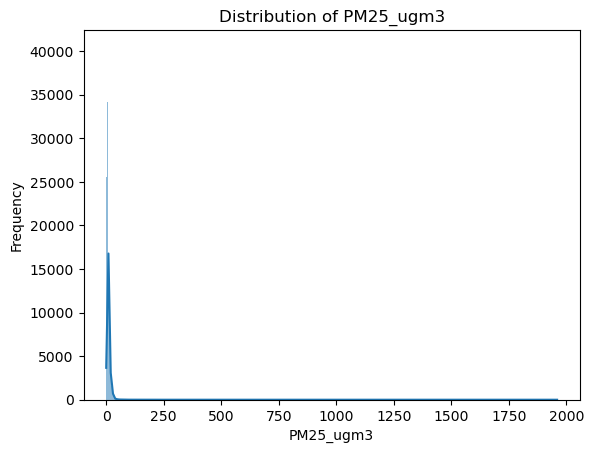

In [10]:
sns.histplot(data=pollution, x=pollution["PM25_ugm3"], kde=True)
plt.title(f"Distribution of PM25_ugm3")
plt.xlabel("PM25_ugm3")
plt.ylabel('Frequency')

In [11]:
# The graph shows lot of outliers(possible values, but very rare occations like taking measurements on the exaust pipes or near furnace)
# lets also check which locations corresponds to these outliers

# Map View 

In [12]:
def define_outlier(df, threshold_percentile=99.95):

    # Percentile method (top 0.01% highest)
    upper_threshold = df['PM25_ugm3'].quantile(threshold_percentile / 100)
    df['is_outlier'] = (df['PM25_ugm3'] > upper_threshold)
    return df[['latitude', 'longitude', 'PM25_ugm3', 'is_outlier']]

df = pollution.copy()

outliers_df = define_outlier(df)
print(f"Outliers detected: {outliers_df['is_outlier'].sum()} ({outliers_df['is_outlier'].mean()*100:.2f}%)")
print(f"Thresholds used:\n  Max Threshold: {outliers_df['PM25_ugm3'][~outliers_df['is_outlier']].max():.2f}")


Outliers detected: 2471 (0.05%)
Thresholds used:
  Max Threshold: 114.78


In [13]:
from folium import Map, Marker
from folium.features import DivIcon  # For custom HTML/CSS icons

# 1. Create the Map (Centered on Dublin)
m = Map(location=[53.3498, -6.2603], zoom_start=13)
m.title = "Dublin PM2.5 Outlier Locations (Fixed Size)"

size_px= 50

# 2. Separate Data
outliers = outliers_df[outliers_df['is_outlier']]   # Red dots
normal = outliers_df[~outliers_df['is_outlier']]   # blue dots

normal = normal.sample(frac=0.0002, random_state=42)


def get_dot_html(color, size_px=8):
    return f"""<div style="width:{size_px}px; height:{size_px}px; 
                border-radius:50%; background-color:{color}; 
                transform:translate(50%,50%);">
    </div>"""


def create_marker(loc, color):
    # Use DivIcon to enforce pixel-based size
    div_icon = DivIcon(html=get_dot_html(color), icon_size=(size_px, size_px))
    return Marker(location=loc, icon=div_icon)

# Add Outliers (Red Dots)
for _, row in outliers.iterrows():
    loc = [row['latitude'], row['longitude']]
    m.add_child(create_marker(loc, 'red'))

# Add Normal Readings (blue Dots)
for _, row in normal.iterrows():
    loc = [row['latitude'], row['longitude']]
    m.add_child(create_marker(loc, 'blue'))

# 6. Save the Map
m.save('dublin_outliers_fixed_map.html')
print("Interactive map saved as 'dublin_outliers_fixed_map.html'")
print("Open this file in Chrome to verify fixed dot sizes.")


Interactive map saved as 'dublin_outliers_fixed_map.html'
Open this file in Chrome to verify fixed dot sizes.


## From the map, the outlieres are spread throughout the area and are concentrated in tunnels and some locations which doesnt have any wind movement where the partical get accumulated.
## Thus, the outliers are possible values, so to normalize the outliers, lets just remove top 0.05% of data. The max threshold for top 0.05% is 115 PM25_ugm3

In [14]:
print(pollution["PM25_ugm3"].describe())
pollution=pollution[pollution["PM25_ugm3"]<115]
pollution["PM25_ugm3"].describe()

count    4.940266e+06
mean     7.976111e+00
std      8.545271e+00
min      7.100000e-02
25%      3.574000e+00
50%      6.097000e+00
75%      1.012800e+01
max      1.960163e+03
Name: PM25_ugm3, dtype: float64


count    4.937808e+06
mean     7.882777e+00
std      6.882625e+00
min      7.100000e-02
25%      3.573000e+00
50%      6.094000e+00
75%      1.011900e+01
max      1.149890e+02
Name: PM25_ugm3, dtype: float64

Text(0, 0.5, 'Frequency')

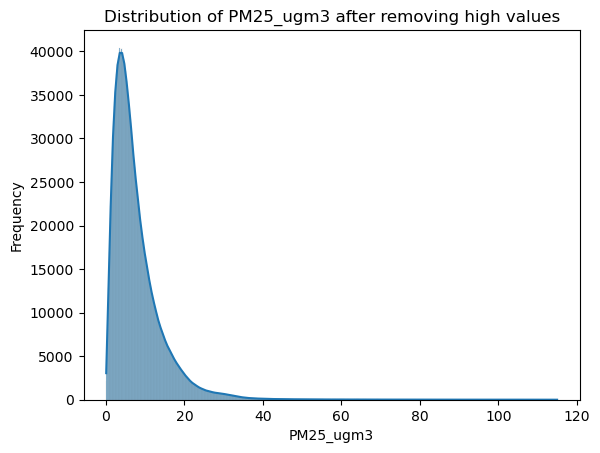

In [15]:
sns.histplot(data=pollution, x=pollution["PM25_ugm3"], kde=True)
plt.title(f"Distribution of PM25_ugm3 after removing high values")
plt.xlabel("PM25_ugm3")
plt.ylabel('Frequency')

In [16]:
# Now the pollution data is clean and ready for further analysis and engineering.
# The goal is to build a model to predict PM2.5 levels for the city of Dublin, in the pollution dataset, there is no other features that will directly alter the level of PM2.5, so lets do some data augmentation and Feature engineering.

# Feature Engineering
## Introducing weather data to enrich pollution data. 

In [36]:
weather = pd.read_csv(r"C:\Users\mugil\Desktop\Pollution_Forecast_Dublin\data\extracted\weather\hly532.csv", skiprows=23)
weather_info = pd.read_csv(r"C:\Users\mugil\Desktop\Pollution_Forecast_Dublin\data\extracted\weather\hly532.csv", skiprows=range(1,6), nrows=16)
print(weather.columns.tolist())
print(weather["date"])

['date', 'ind', 'rain', 'ind.1', 'temp', 'ind.2', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'ind.3', 'wdsp', 'ind.4', 'wddir', 'ww', 'w', 'sun', 'vis', 'clht', 'clamt']
0         01-jan-1943 00:00
1         01-jan-1943 01:00
2         01-jan-1943 02:00
3         01-jan-1943 03:00
4         01-jan-1943 04:00
                ...        
703436    31-mar-2023 20:00
703437    31-mar-2023 21:00
703438    31-mar-2023 22:00
703439    31-mar-2023 23:00
703440    01-apr-2023 00:00
Name: date, Length: 703441, dtype: str


C:\Users\mugil\AppData\Local\Temp\ipykernel_13412\1466537766.py:1: DtypeWarning: Columns (0: vappr, 1: rhum, 2: wddir, 3: vis, 4: clht, 5: clamt) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv(r"C:\Users\mugil\Desktop\Pollution_Forecast_Dublin\data\extracted\weather\hly532.csv", skiprows=23)


In [18]:
pollution.sort_values(by="gps_timestamp")

,gps_timestamp,latitude,longitude,PM25_ugm3
286306,2021-05-06 07:35:36 UTC,53.340676,-6.331877,3.668
286307,2021-05-06 07:35:37 UTC,53.340690,-6.331805,5.004
286308,2021-05-06 07:35:38 UTC,53.340704,-6.331724,3.854
286309,2021-05-06 07:35:39 UTC,53.340720,-6.331639,6.041
286310,2021-05-06 07:35:40 UTC,53.340736,-6.331554,4.928
...,...,...,...,...
2981505,2022-08-05 15:27:38 UTC,53.339444,-6.238422,3.904
2981506,2022-08-05 15:27:39 UTC,53.339444,-6.238422,6.536
2981507,2022-08-05 15:27:40 UTC,53.339444,-6.238422,4.424
2981508,2022-08-05 15:27:41 UTC,53.339444,-6.238422,3.546


# The data starts from 1943 till 2023, but the pollution is only avilable for 2021-05-06 to 2022-08-05. 
# lets filter this first 

In [19]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 703441 entries, 0 to 703440
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    703441 non-null  str    
 1   ind     703441 non-null  int64  
 2   rain    703441 non-null  float64
 3   ind.1   703441 non-null  int64  
 4   temp    703441 non-null  float64
 5   ind.2   703441 non-null  int64  
 6   wetb    703441 non-null  float64
 7   dewpt   703441 non-null  float64
 8   vappr   703441 non-null  object 
 9   rhum    703441 non-null  object 
 10  msl     703441 non-null  float64
 11  ind.3   703441 non-null  int64  
 12  wdsp    703441 non-null  int64  
 13  ind.4   703441 non-null  int64  
 14  wddir   703441 non-null  object 
 15  ww      703441 non-null  int64  
 16  w       703441 non-null  int64  
 17  sun     703441 non-null  float64
 18  vis     703441 non-null  object 
 19  clht    703441 non-null  object 
 20  clamt   703441 non-null  object 
dtypes: float64(6), int64(

In [20]:
# Changing column name and converting str to date time format
weather.rename(columns={"date": "gps_timestamp"}, inplace=True)

weather['gps_timestamp'] = pd.to_datetime(weather['gps_timestamp'],
                                             format="%d-%b-%Y %H:%M",
                                             errors='coerce')

## Also when we look at the time stamp of pollution data, it only avilable from morning 7 hours to evening 21 hours. filtering weather data for this condition 

In [21]:
weather['hour'] = weather['gps_timestamp'].dt.hour
weather = weather[(weather['hour'] > 6.0) & (weather['hour'] <= 20.0)]

In [22]:
weather = weather[(weather["gps_timestamp"]>'2021-05-06 00:00:00')&(weather["gps_timestamp"]<'2022-08-06 00:00:00')].reset_index(drop=True)

In [23]:
weather.describe()

,gps_timestamp,ind,rain,ind.1,temp,ind.2,wetb,dewpt,msl,ind.3,wdsp,ind.4,ww,w,sun,hour
count,6398,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000,6398.000000
mean,2021-12-20 13:29:59.999999,0.331197,0.073617,0.002970,12.450516,0.004689,10.338121,8.214505,1015.785386,2.000313,9.439669,2.000625,13.781182,28.265552,0.303017,13.500000
min,2021-05-06 07:00:00,0.000000,0.000000,0.000000,-3.800000,0.000000,-4.000000,-4.900000,961.800000,2.000000,1.000000,2.000000,1.000000,0.000000,0.000000,7.000000
25%,2021-08-28 10:15:00,0.000000,0.000000,0.000000,8.800000,0.000000,7.300000,5.100000,1009.000000,2.000000,6.000000,2.000000,2.000000,11.000000,0.000000,10.000000
50%,2021-12-20 13:30:00,0.000000,0.000000,0.000000,12.750000,0.000000,10.600000,8.200000,1017.000000,2.000000,9.000000,2.000000,2.000000,11.000000,0.100000,13.500000
75%,2022-04-13 16:45:00,0.000000,0.000000,0.000000,16.100000,0.000000,13.600000,11.675000,1023.600000,2.000000,12.000000,2.000000,20.000000,55.750000,0.600000,17.000000
max,2022-08-05 20:00:00,3.000000,10.300000,1.000000,29.100000,1.000000,20.300000,19.100000,1042.100000,4.000000,35.000000,4.000000,91.000000,98.000000,1.000000,20.000000
std,NaN,0.783126,0.357970,0.054418,4.999006,0.068321,4.248544,4.353821,11.578211,0.025004,4.261945,0.035358,22.187407,26.837825,0.383918,4.031444


## Checking null values

In [24]:
weather.isnull().sum()

gps_timestamp    0
ind              0
rain             0
ind.1            0
temp             0
ind.2            0
wetb             0
dewpt            0
vappr            0
rhum             0
msl              0
ind.3            0
wdsp             0
ind.4            0
wddir            0
ww               0
w                0
sun              0
vis              0
clht             0
clamt            0
hour             0
dtype: int64

# Joining pollution data and the Weather data

In [29]:
pollution['gps_timestamp'] = pd.to_datetime(pollution['gps_timestamp'], utc=True)
weather['gps_timestamp'] = pd.to_datetime(weather['gps_timestamp'], utc=True)
pollution['date_hour'] = pollution['gps_timestamp'].dt.floor('h')
weather['date_hour'] = weather['gps_timestamp'].dt.floor('h')

pollution = pd.merge(
    pollution,
    weather,
    on='date_hour',
    how='left',  # Retain all pollution data rows
    suffixes=('', '_weather')  # Handle overlapping column names
    )

In [30]:
pollution

,gps_timestamp,latitude,longitude,PM25_ugm3,date_hour,gps_timestamp_weather,ind,rain,ind.1,temp,...,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt,hour
0,2022-04-07 14:56:36+00:00,53.346434,-6.263997,4.927,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
1,2022-04-07 14:56:37+00:00,53.346434,-6.263997,4.240,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
2,2022-04-07 14:56:38+00:00,53.346434,-6.263997,4.204,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
3,2022-04-07 14:56:39+00:00,53.346434,-6.263997,3.410,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
4,2022-04-07 14:56:40+00:00,53.346434,-6.263997,4.003,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4937803,2022-04-07 14:56:31+00:00,53.346434,-6.263997,4.169,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
4937804,2022-04-07 14:56:32+00:00,53.346434,-6.263997,5.207,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
4937805,2022-04-07 14:56:33+00:00,53.346434,-6.263997,3.463,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0
4937806,2022-04-07 14:56:34+00:00,53.346434,-6.263997,4.740,2022-04-07 14:00:00+00:00,2022-04-07 14:00:00+00:00,2.0,0.0,0.0,10.4,...,18.0,2.0,320,80.0,82.0,0.7,30000,40,6,14.0


In [31]:
print(pollution.columns.tolist())

['gps_timestamp', 'latitude', 'longitude', 'PM25_ugm3', 'date_hour', 'gps_timestamp_weather', 'ind', 'rain', 'ind.1', 'temp', 'ind.2', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'ind.3', 'wdsp', 'ind.4', 'wddir', 'ww', 'w', 'sun', 'vis', 'clht', 'clamt', 'hour']


In [38]:
weather_info

,Station Name: DUBLIN AIRPORT
0,rain: - Precipitation Amount (mm)\t
1,temp: - Air Temperature (C)\t
2,wetb: - Wet Bulb Temperature (C)
3,dewpt: - Dew Point Temperature (C)
4,rhum: - Relative Humidity (%)
5,vappr: - Vapour Pressure (hPa)\t
6,msl: - Mean Sea Level Pressure (hPa)
7,wdsp: - Mean Wind Speed (knot)
8,wddir: - Predominant Wind Direction (degree)
9,ww: - Synop code for Present Weather


# Drop all columns that doesnt effect pollution and isn't helpful in pollution prediction 

In [40]:
pollution.drop(['date_hour', 'gps_timestamp_weather', 'ind', 'ind.1', 'ind.2', 'wetb', 'dewpt', 'vappr', 'msl', 'ind.3', 'ind.4', 'ww', 'w', 'sun', 'vis', 'clht', 'clamt'], axis=1)

,gps_timestamp,latitude,longitude,PM25_ugm3,rain,temp,rhum,wdsp,wddir,hour
0,2022-04-07 14:56:36+00:00,53.346434,-6.263997,4.927,0.0,10.4,52,18.0,320,14.0
1,2022-04-07 14:56:37+00:00,53.346434,-6.263997,4.240,0.0,10.4,52,18.0,320,14.0
2,2022-04-07 14:56:38+00:00,53.346434,-6.263997,4.204,0.0,10.4,52,18.0,320,14.0
3,2022-04-07 14:56:39+00:00,53.346434,-6.263997,3.410,0.0,10.4,52,18.0,320,14.0
4,2022-04-07 14:56:40+00:00,53.346434,-6.263997,4.003,0.0,10.4,52,18.0,320,14.0
...,...,...,...,...,...,...,...,...,...,...
4937803,2022-04-07 14:56:31+00:00,53.346434,-6.263997,4.169,0.0,10.4,52,18.0,320,14.0
4937804,2022-04-07 14:56:32+00:00,53.346434,-6.263997,5.207,0.0,10.4,52,18.0,320,14.0
4937805,2022-04-07 14:56:33+00:00,53.346434,-6.263997,3.463,0.0,10.4,52,18.0,320,14.0
4937806,2022-04-07 14:56:34+00:00,53.346434,-6.263997,4.740,0.0,10.4,52,18.0,320,14.0
